# 📊 Exploratory Data Analysis (EDA)
## Credit Scoring - Give Me Some Credit

**Author**: QuangMinh  
**Course**: MLE501 - AI & Machine Learning  
**Date**: 2026-03-09

---

## 🎯 Objectives
1. Load và hiểu cấu trúc dữ liệu
2. Phân tích thống kê mô tả
3. Phát hiện missing values
4. Phát hiện outliers
5. Phân tích phân phối của features
6. Phân tích correlation
7. Kiểm tra class imbalance
8. Insights & Recommendations

## 📦 Import Libraries

In [64]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency

# Utilities
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Create output directory
FIGURES_DIR = '../reports/[1] Ket qua EDA/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Load Data

In [65]:
# Load training data
train_df = pd.read_csv('../data/raw/cs-training.csv')

print(f"✅ Training data loaded: {train_df.shape}")

✅ Training data loaded: (150000, 12)


## 1️⃣ Data Overview

In [66]:
# Display first few rows
print("="*80)
print("FIRST 10 ROWS OF TRAINING DATA")
print("="*80)
display(train_df.head(10))

FIRST 10 ROWS OF TRAINING DATA


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766,45,2,0.803,9120.000,13,0,6,0,2.000
1,2,0,0.957,40,0,0.122,2600.000,4,0,0,0,1.000
2,3,0,0.658,38,1,0.085,3042.000,2,1,0,0,0.000
3,4,0,0.234,30,0,0.036,3300.000,5,0,0,0,0.000
4,5,0,0.907,49,1,0.025,63588.000,7,0,1,0,0.000
5,6,0,0.213,74,0,0.376,3500.000,3,0,1,0,1.000
6,7,0,0.306,57,0,5710.000,NaN,8,0,3,0,0.000
7,8,0,0.754,39,0,0.210,3500.000,8,0,0,0,0.000
8,9,0,0.117,27,0,46.000,NaN,2,0,0,0,NaN
9,10,0,0.189,57,0,0.606,23684.000,9,0,4,0,2.000


In [67]:
# Basic information
print("="*80)
print("DATA INFO")
print("="*80)
print(f"\nTraining set shape: {train_df.shape}")
print(f"\nNumber of features: {train_df.shape[1] - 1}")
print(f"Number of samples: {train_df.shape[0]:,}")
print("\n" + "="*80)
train_df.info()

DATA INFO

Training set shape: (150000, 12)

Number of features: 11
Number of samples: 150,000

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          15

In [68]:
# Check for unnamed index column
print("Column names:")
print(train_df.columns.tolist())

# Drop the unnamed index column if exists
if 'Unnamed: 0' in train_df.columns:
    train_df = train_df.drop('Unnamed: 0', axis=1)
    print("\n✅ Dropped 'Unnamed: 0' column")

print(f"\nFinal shape: {train_df.shape}")

Column names:
['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

✅ Dropped 'Unnamed: 0' column

Final shape: (150000, 11)


## 2️⃣ Descriptive Statistics

In [69]:
# Descriptive statistics
print("="*80)
print("DESCRIPTIVE STATISTICS - TRAINING DATA")
print("="*80)
display(train_df.describe().T)

DESCRIPTIVE STATISTICS - TRAINING DATA


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.000,0.067,0.250,0.000,0.000,0.000,0.000,1.000
RevolvingUtilizationOfUnsecuredLines,150000.000,6.048,249.755,0.000,0.030,0.154,0.559,50708.000
age,150000.000,52.295,14.772,0.000,41.000,52.000,63.000,109.000
NumberOfTime30-59DaysPastDueNotWorse,150000.000,0.421,4.193,0.000,0.000,0.000,0.000,98.000
DebtRatio,150000.000,353.005,2037.819,0.000,0.175,0.367,0.868,329664.000
MonthlyIncome,120269.000,6670.221,14384.674,0.000,3400.000,5400.000,8249.000,3008750.000
NumberOfOpenCreditLinesAndLoans,150000.000,8.453,5.146,0.000,5.000,8.000,11.000,58.000
NumberOfTimes90DaysLate,150000.000,0.266,4.169,0.000,0.000,0.000,0.000,98.000
NumberRealEstateLoansOrLines,150000.000,1.018,1.130,0.000,0.000,1.000,2.000,54.000
NumberOfTime60-89DaysPastDueNotWorse,150000.000,0.240,4.155,0.000,0.000,0.000,0.000,98.000


In [70]:
# Create a summary statistics table
def create_summary_stats(df):
    """
    Create comprehensive summary statistics
    """
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'count': df.count(),
        'missing': df.isnull().sum(),
        'missing_%': (df.isnull().sum() / len(df) * 100).round(2),
        'unique': df.nunique(),
        'mean': df.mean(numeric_only=True),
        'std': df.std(numeric_only=True),
        'min': df.min(numeric_only=True),
        'q25': df.quantile(0.25, numeric_only=True),
        'median': df.median(numeric_only=True),
        'q75': df.quantile(0.75, numeric_only=True),
        'max': df.max(numeric_only=True),
        'skewness': df.skew(numeric_only=True),
        'kurtosis': df.kurtosis(numeric_only=True)
    })
    return summary

summary_stats = create_summary_stats(train_df)
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*80)
display(summary_stats)


COMPREHENSIVE SUMMARY STATISTICS


,dtype,count,missing,missing_%,unique,mean,std,min,q25,median,q75,max,skewness,kurtosis
SeriousDlqin2yrs,int64,150000,0,0.000,2,0.067,0.250,0.000,0.000,0.000,0.000,1.000,3.469,10.033
RevolvingUtilizationOfUnsecuredLines,float64,150000,0,0.000,125728,6.048,249.755,0.000,0.030,0.154,0.559,50708.000,97.632,14544.713
age,int64,150000,0,0.000,86,52.295,14.772,0.000,41.000,52.000,63.000,109.000,0.189,-0.495
NumberOfTime30-59DaysPastDueNotWorse,int64,150000,0,0.000,16,0.421,4.193,0.000,0.000,0.000,0.000,98.000,22.597,522.377
DebtRatio,float64,150000,0,0.000,114194,353.005,2037.819,0.000,0.175,0.367,0.868,329664.000,95.158,13734.289
MonthlyIncome,float64,120269,29731,19.820,13594,6670.221,14384.674,0.000,3400.000,5400.000,8249.000,3008750.000,114.040,19504.705
NumberOfOpenCreditLinesAndLoans,int64,150000,0,0.000,58,8.453,5.146,0.000,5.000,8.000,11.000,58.000,1.215,3.091
NumberOfTimes90DaysLate,int64,150000,0,0.000,19,0.266,4.169,0.000,0.000,0.000,0.000,98.000,23.087,537.739
NumberRealEstateLoansOrLines,int64,150000,0,0.000,28,1.018,1.130,0.000,0.000,1.000,2.000,54.000,3.482,60.477
NumberOfTime60-89DaysPastDueNotWorse,int64,150000,0,0.000,13,0.240,4.155,0.000,0.000,0.000,0.000,98.000,23.332,545.683


## 3️⃣ Missing Values Analysis

In [71]:
# Missing values analysis
def analyze_missing_values(df, df_name='Data'):
    """
    Analyze missing values in the dataset
    """
    missing = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum().values,
        'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2),
        'Data_Type': df.dtypes.values
    })
    missing = missing[missing['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
    
    print(f"\n{'='*80}")
    print(f"MISSING VALUES ANALYSIS - {df_name}")
    print(f"{'='*80}")
    
    if len(missing) == 0:
        print("✅ No missing values found!")
    else:
        print(f"\n⚠️  Found {len(missing)} columns with missing values:\n")
        display(missing)
    
    return missing

missing_train = analyze_missing_values(train_df, 'Training Set')


MISSING VALUES ANALYSIS - Training Set

⚠️  Found 2 columns with missing values:



,Column,Missing_Count,Missing_Percentage,Data_Type
5,MonthlyIncome,29731,19.820,float64
10,NumberOfDependents,3924,2.620,float64


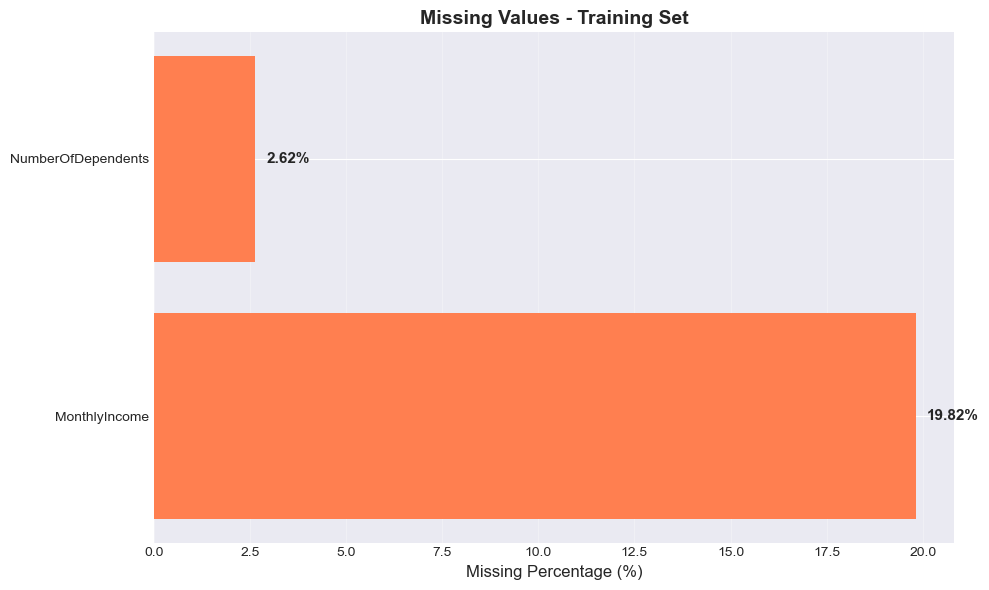

In [72]:
# Visualize missing values
if len(missing_train) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.barh(missing_train['Column'], missing_train['Missing_Percentage'], color='coral')
    ax.set_xlabel('Missing Percentage (%)', fontsize=12)
    ax.set_title('Missing Values - Training Set', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add percentage labels
    for i, (col, pct) in enumerate(zip(missing_train['Column'], missing_train['Missing_Percentage'])):
        ax.text(pct + 0.3, i, f'{pct:.2f}%', va='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + '01_missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No missing values to visualize.")

## 4️⃣ Target Variable Analysis

In [73]:
# Target variable analysis
target_col = 'SeriousDlqin2yrs'

print("="*80)
print("TARGET VARIABLE ANALYSIS")
print("="*80)

# Value counts
target_counts = train_df[target_col].value_counts().sort_index()
target_pct = train_df[target_col].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_pct.round(2)
}, index=['Class 0 (Good)', 'Class 1 (Bad)'])

print("\nClass Distribution:")
display(target_summary)

# Imbalance ratio
imbalance_ratio = target_counts.iloc[0] / target_counts.iloc[1]
print(f"\n⚠️  Imbalance Ratio (Class 0 : Class 1) = {imbalance_ratio:.2f} : 1")
print(f"    → Class 0 (Good customers) is {imbalance_ratio:.2f}x more than Class 1")

TARGET VARIABLE ANALYSIS

Class Distribution:


,Count,Percentage
Class 0 (Good),NaN,NaN
Class 1 (Bad),NaN,NaN



⚠️  Imbalance Ratio (Class 0 : Class 1) = 13.96 : 1
    → Class 0 (Good customers) is 13.96x more than Class 1


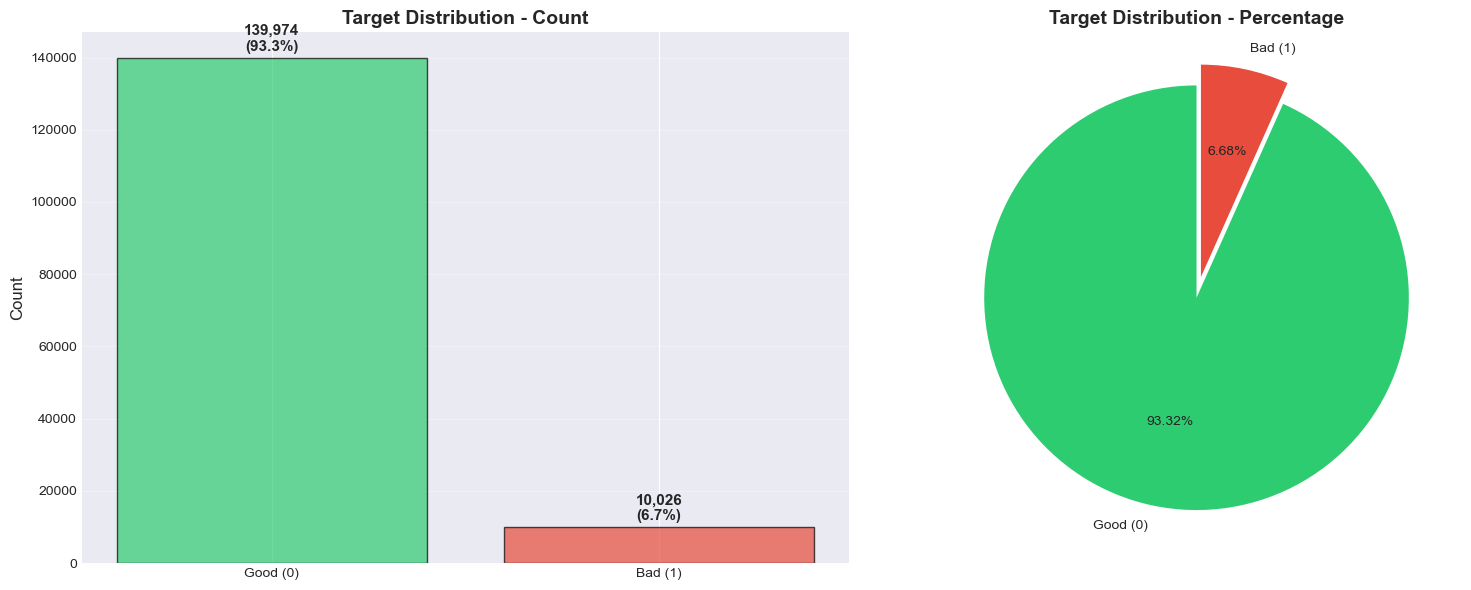

In [74]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Good (0)', 'Bad (1)'], target_counts.values, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Target Distribution - Count', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({target_pct.values[i]:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Good (0)', 'Bad (1)'], autopct='%1.2f%%',
           colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Target Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR + '02_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5️⃣ Feature Distributions

In [75]:
# Get numerical features (excluding target)
numerical_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numerical_features:
    numerical_features.remove(target_col)

print(f"Numerical features ({len(numerical_features)}):")
for i, feature in enumerate(numerical_features, 1):
    print(f"  {i}. {feature}")

Numerical features (10):
  1. RevolvingUtilizationOfUnsecuredLines
  2. age
  3. NumberOfTime30-59DaysPastDueNotWorse
  4. DebtRatio
  5. MonthlyIncome
  6. NumberOfOpenCreditLinesAndLoans
  7. NumberOfTimes90DaysLate
  8. NumberRealEstateLoansOrLines
  9. NumberOfTime60-89DaysPastDueNotWorse
  10. NumberOfDependents


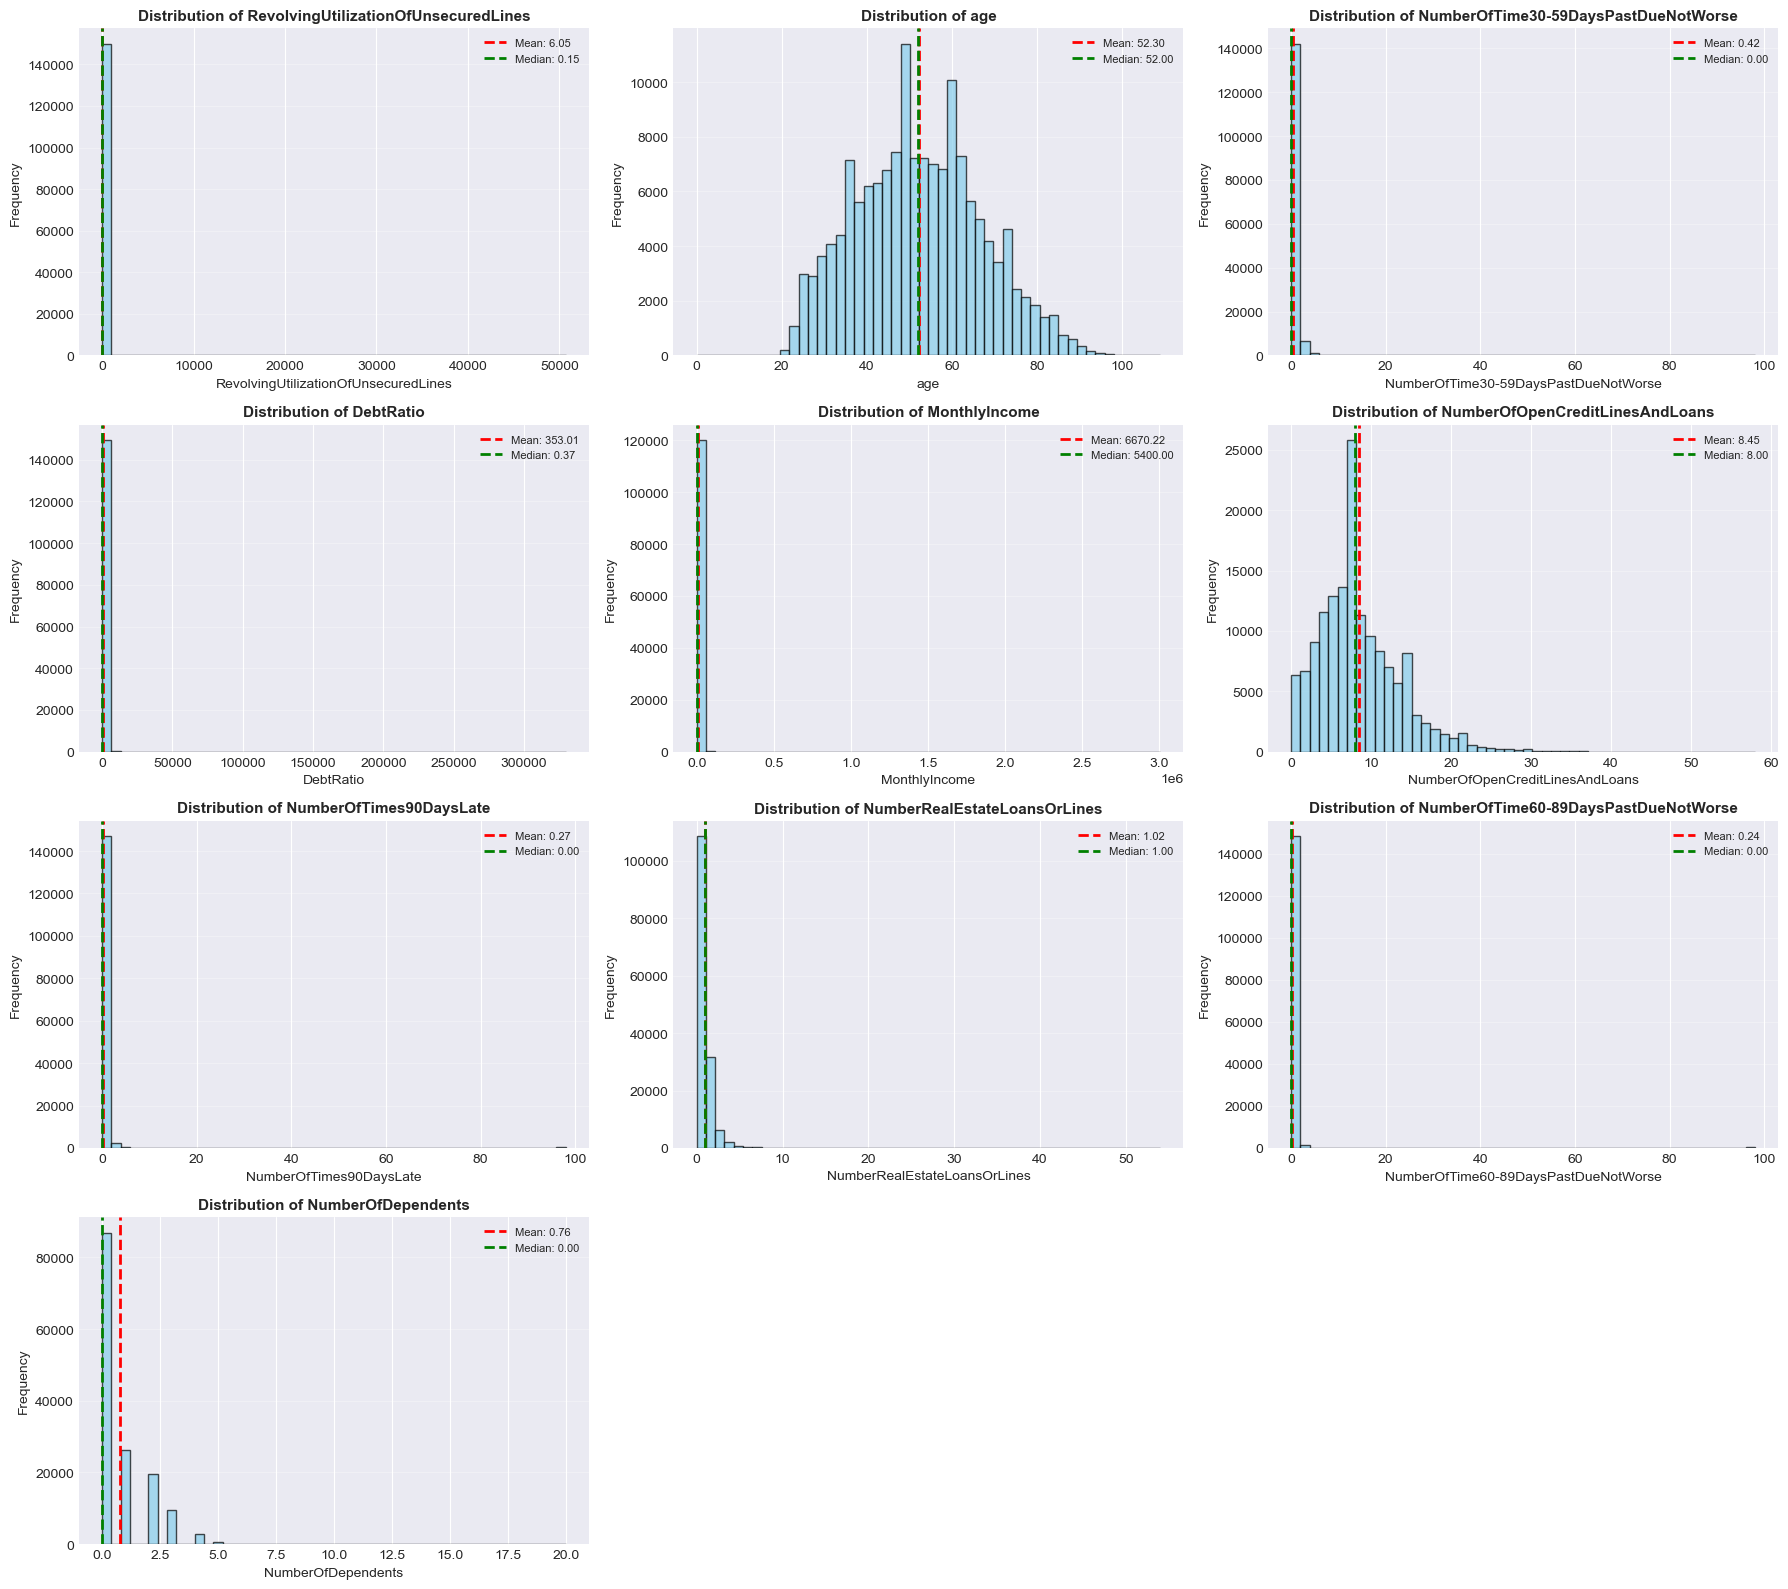

In [76]:
# Plot distributions of all numerical features
def plot_distributions(df, features, ncols=3):
    """
    Plot distributions of numerical features
    """
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*4))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    
    for idx, feature in enumerate(features):
        # Remove NaN for plotting
        data = df[feature].dropna()
        
        # Histogram
        axes[idx].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add statistics
        mean_val = data.mean()
        median_val = data.median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        axes[idx].legend(fontsize=8)
    
    # Hide extra subplots
    for idx in range(len(features), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + '03_feature_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_distributions(train_df, numerical_features, ncols=3)

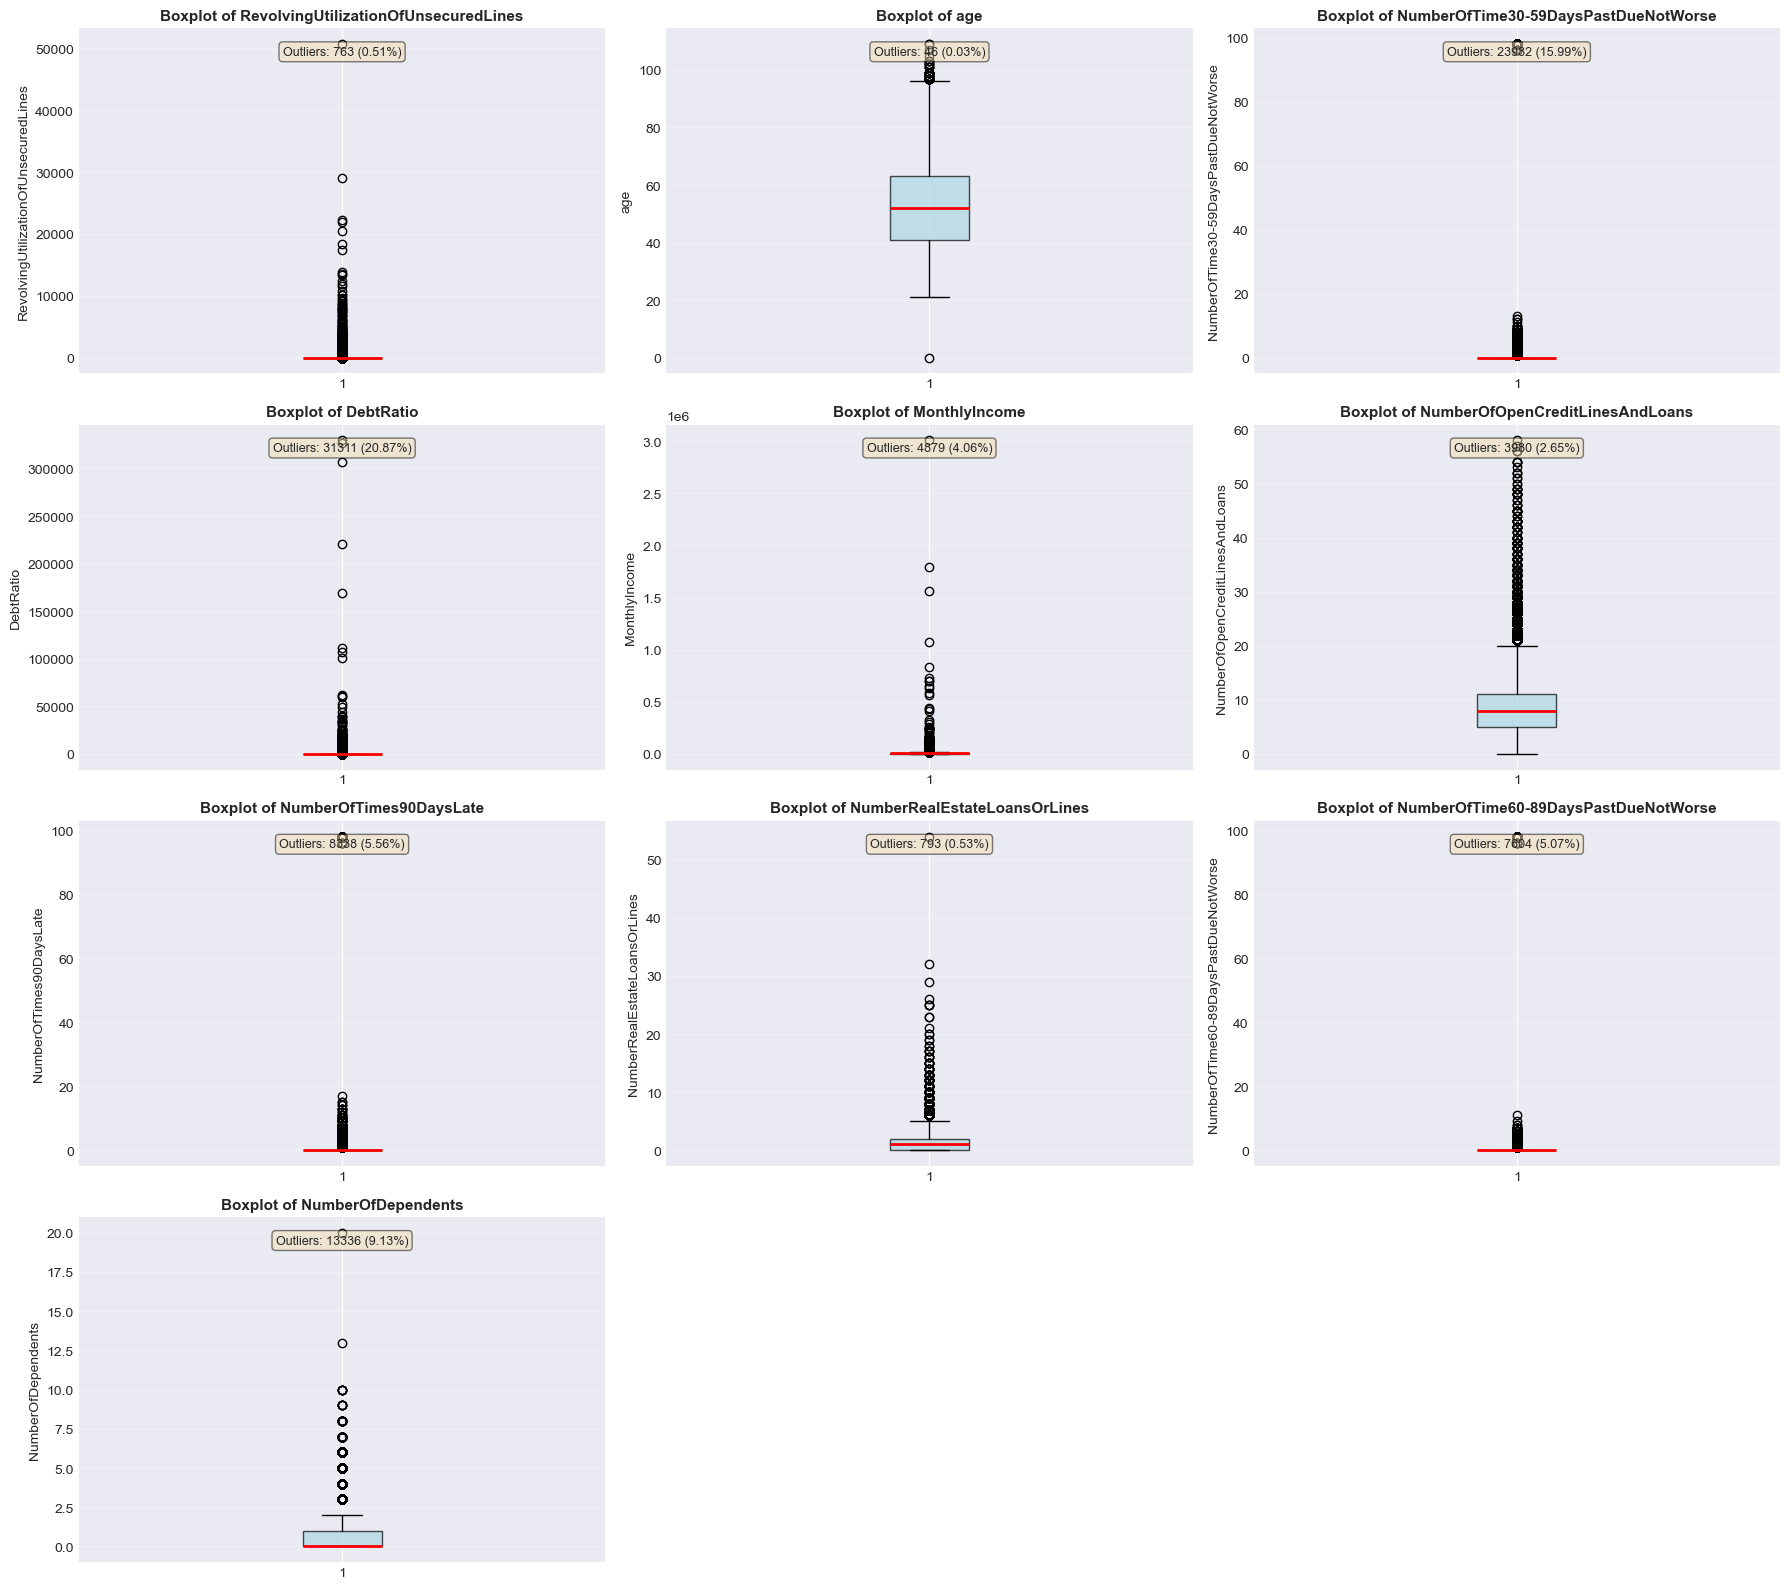

In [77]:
# Box plots to detect outliers
def plot_boxplots(df, features, ncols=3):
    """
    Plot boxplots for outlier detection
    """
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*4))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    
    for idx, feature in enumerate(features):
        # Remove NaN for plotting
        data = df[feature].dropna()
        
        # Boxplot
        axes[idx].boxplot(data, vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
        axes[idx].set_ylabel(feature, fontsize=10)
        axes[idx].set_title(f'Boxplot of {feature}', fontsize=11, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Calculate outliers
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()
        outlier_pct = (outliers / len(data)) * 100
        
        axes[idx].text(0.5, 0.95, f'Outliers: {outliers} ({outlier_pct:.2f}%)',
                      transform=axes[idx].transAxes, ha='center', va='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                      fontsize=9)
    
    # Hide extra subplots
    for idx in range(len(features), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + '04_boxplots_outliers.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_boxplots(train_df, numerical_features, ncols=3)

## 6️⃣ Outlier Analysis

In [78]:
# Detailed outlier analysis
def detect_outliers_iqr(df, feature):
    """
    Detect outliers using IQR method
    """
    data = df[feature].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (data < lower_bound) | (data > upper_bound)
    
    return {
        'feature': feature,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_count': outliers.sum(),
        'outliers_pct': (outliers.sum() / len(data)) * 100,
        'min_value': data.min(),
        'max_value': data.max()
    }

# Analyze outliers for all features
outlier_analysis = []
for feature in numerical_features:
    outlier_analysis.append(detect_outliers_iqr(train_df, feature))

outlier_df = pd.DataFrame(outlier_analysis)
outlier_df = outlier_df.sort_values('outliers_pct', ascending=False)

print("="*80)
print("OUTLIER ANALYSIS (IQR Method)")
print("="*80)
display(outlier_df)

OUTLIER ANALYSIS (IQR Method)


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outliers_count,outliers_pct,min_value,max_value
3,DebtRatio,0.175,0.868,0.693,-0.865,1.908,31311,20.874,0.000,329664.000
2,NumberOfTime30-59DaysPastDueNotWorse,0.000,0.000,0.000,0.000,0.000,23982,15.988,0.000,98.000
9,NumberOfDependents,0.000,1.000,1.000,-1.500,2.500,13336,9.129,0.000,20.000
6,NumberOfTimes90DaysLate,0.000,0.000,0.000,0.000,0.000,8338,5.559,0.000,98.000
8,NumberOfTime60-89DaysPastDueNotWorse,0.000,0.000,0.000,0.000,0.000,7604,5.069,0.000,98.000
4,MonthlyIncome,3400.000,8249.000,4849.000,-3873.500,15522.500,4879,4.057,0.000,3008750.000
5,NumberOfOpenCreditLinesAndLoans,5.000,11.000,6.000,-4.000,20.000,3980,2.653,0.000,58.000
7,NumberRealEstateLoansOrLines,0.000,2.000,2.000,-3.000,5.000,793,0.529,0.000,54.000
0,RevolvingUtilizationOfUnsecuredLines,0.030,0.559,0.529,-0.764,1.353,763,0.509,0.000,50708.000
1,age,41.000,63.000,22.000,8.000,96.000,46,0.031,0.000,109.000


## 7️⃣ Correlation Analysis

In [79]:
# Correlation matrix
correlation_matrix = train_df[numerical_features + [target_col]].corr()

print("="*80)
print("CORRELATION WITH TARGET VARIABLE")
print("="*80)
target_corr = correlation_matrix[target_col].drop(target_col).sort_values(ascending=False)
display(target_corr.to_frame(name='Correlation'))

CORRELATION WITH TARGET VARIABLE


,Correlation
NumberOfTime30-59DaysPastDueNotWorse,0.126
NumberOfTimes90DaysLate,0.117
NumberOfTime60-89DaysPastDueNotWorse,0.102
NumberOfDependents,0.046
RevolvingUtilizationOfUnsecuredLines,-0.002
NumberRealEstateLoansOrLines,-0.007
DebtRatio,-0.008
MonthlyIncome,-0.020
NumberOfOpenCreditLinesAndLoans,-0.030
age,-0.115


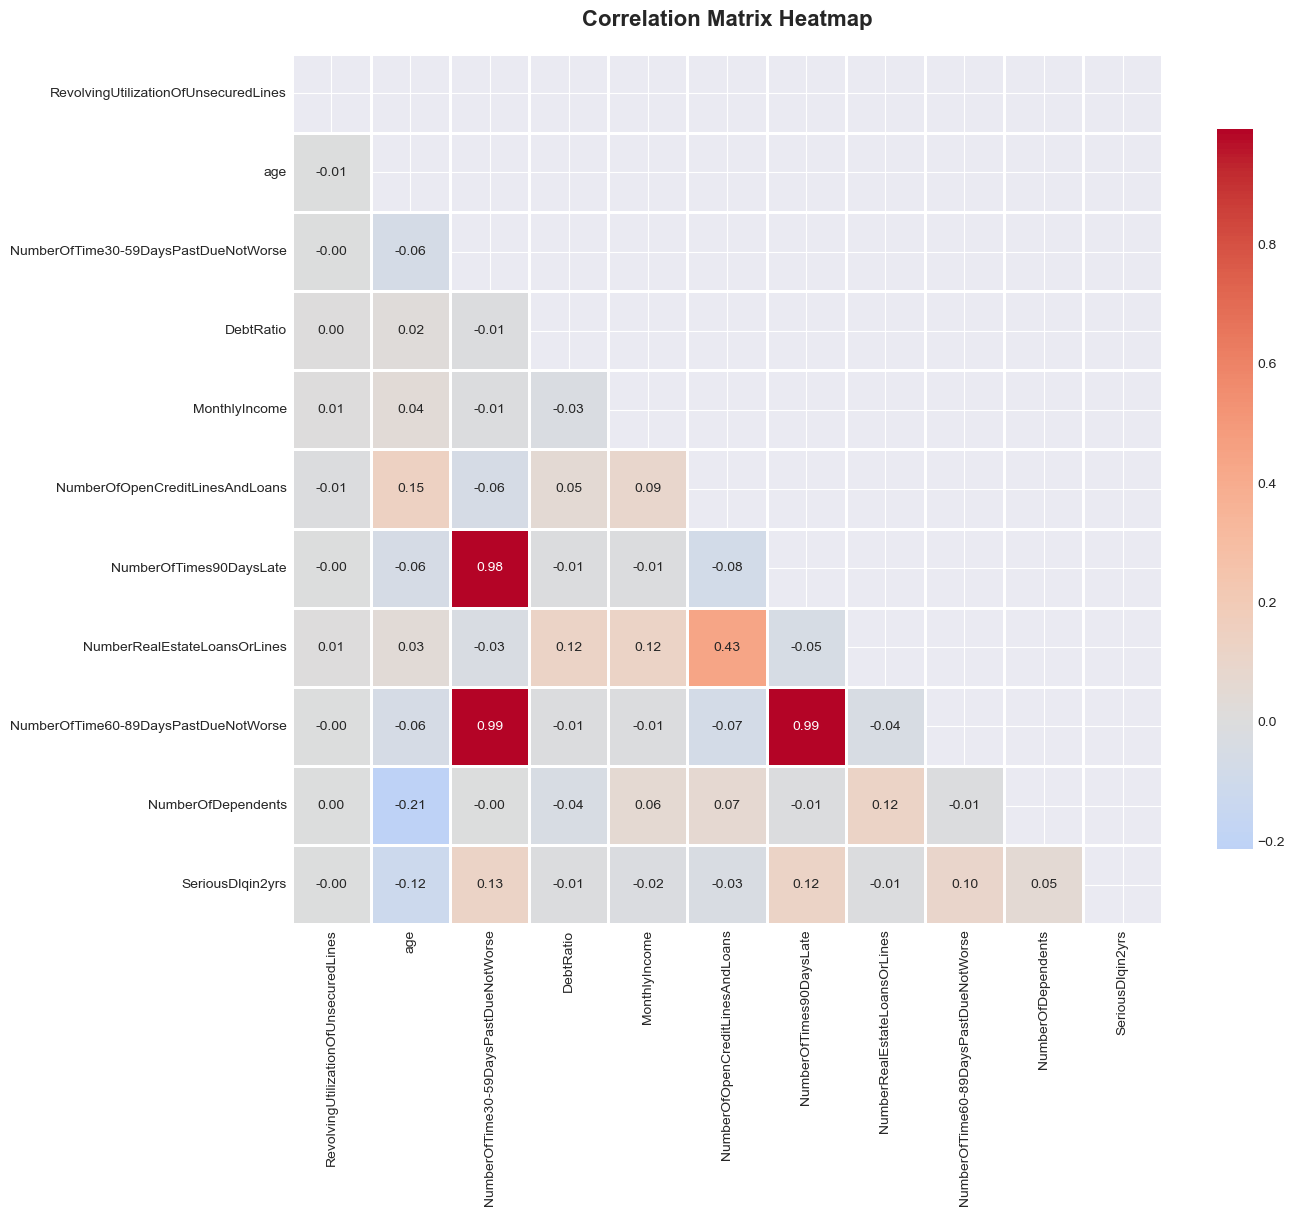

In [80]:
# Heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '05_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

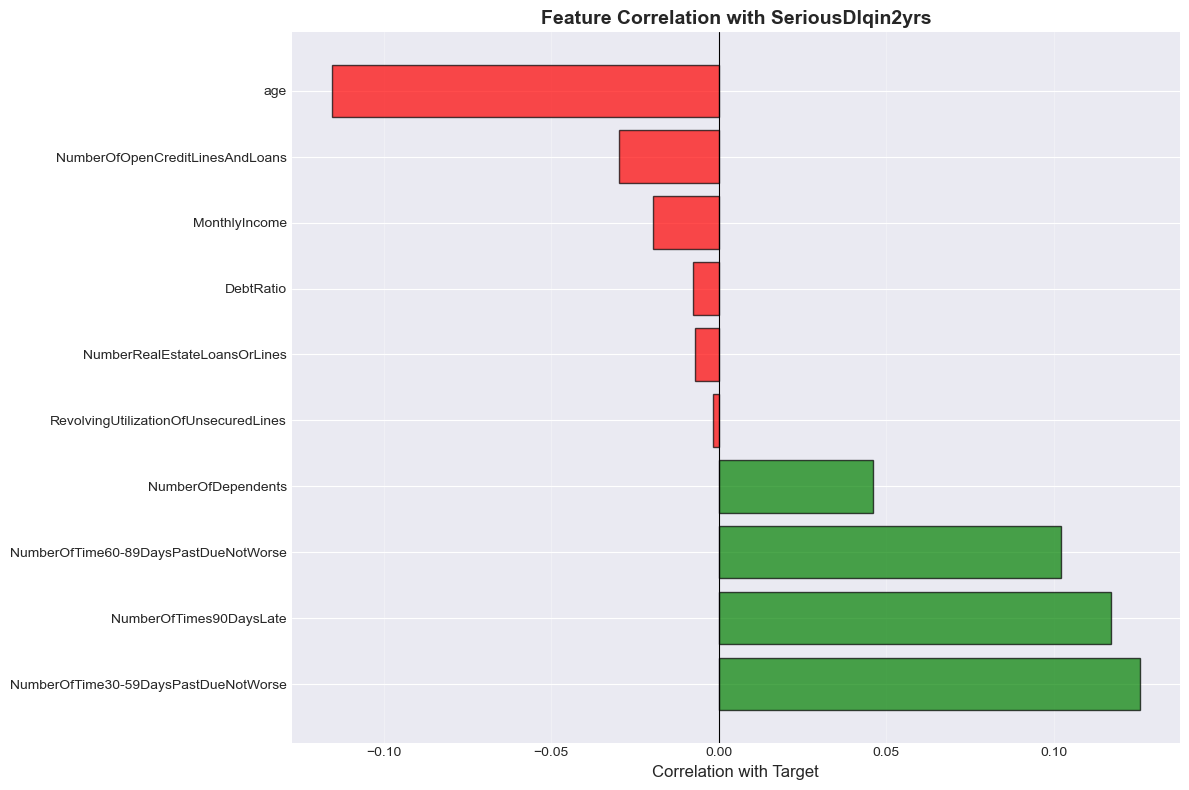

In [81]:
# Bar plot of correlations with target
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Correlation with Target', fontsize=12)
ax.set_title('Feature Correlation with SeriousDlqin2yrs', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '06_target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 8️⃣ Feature vs Target Analysis

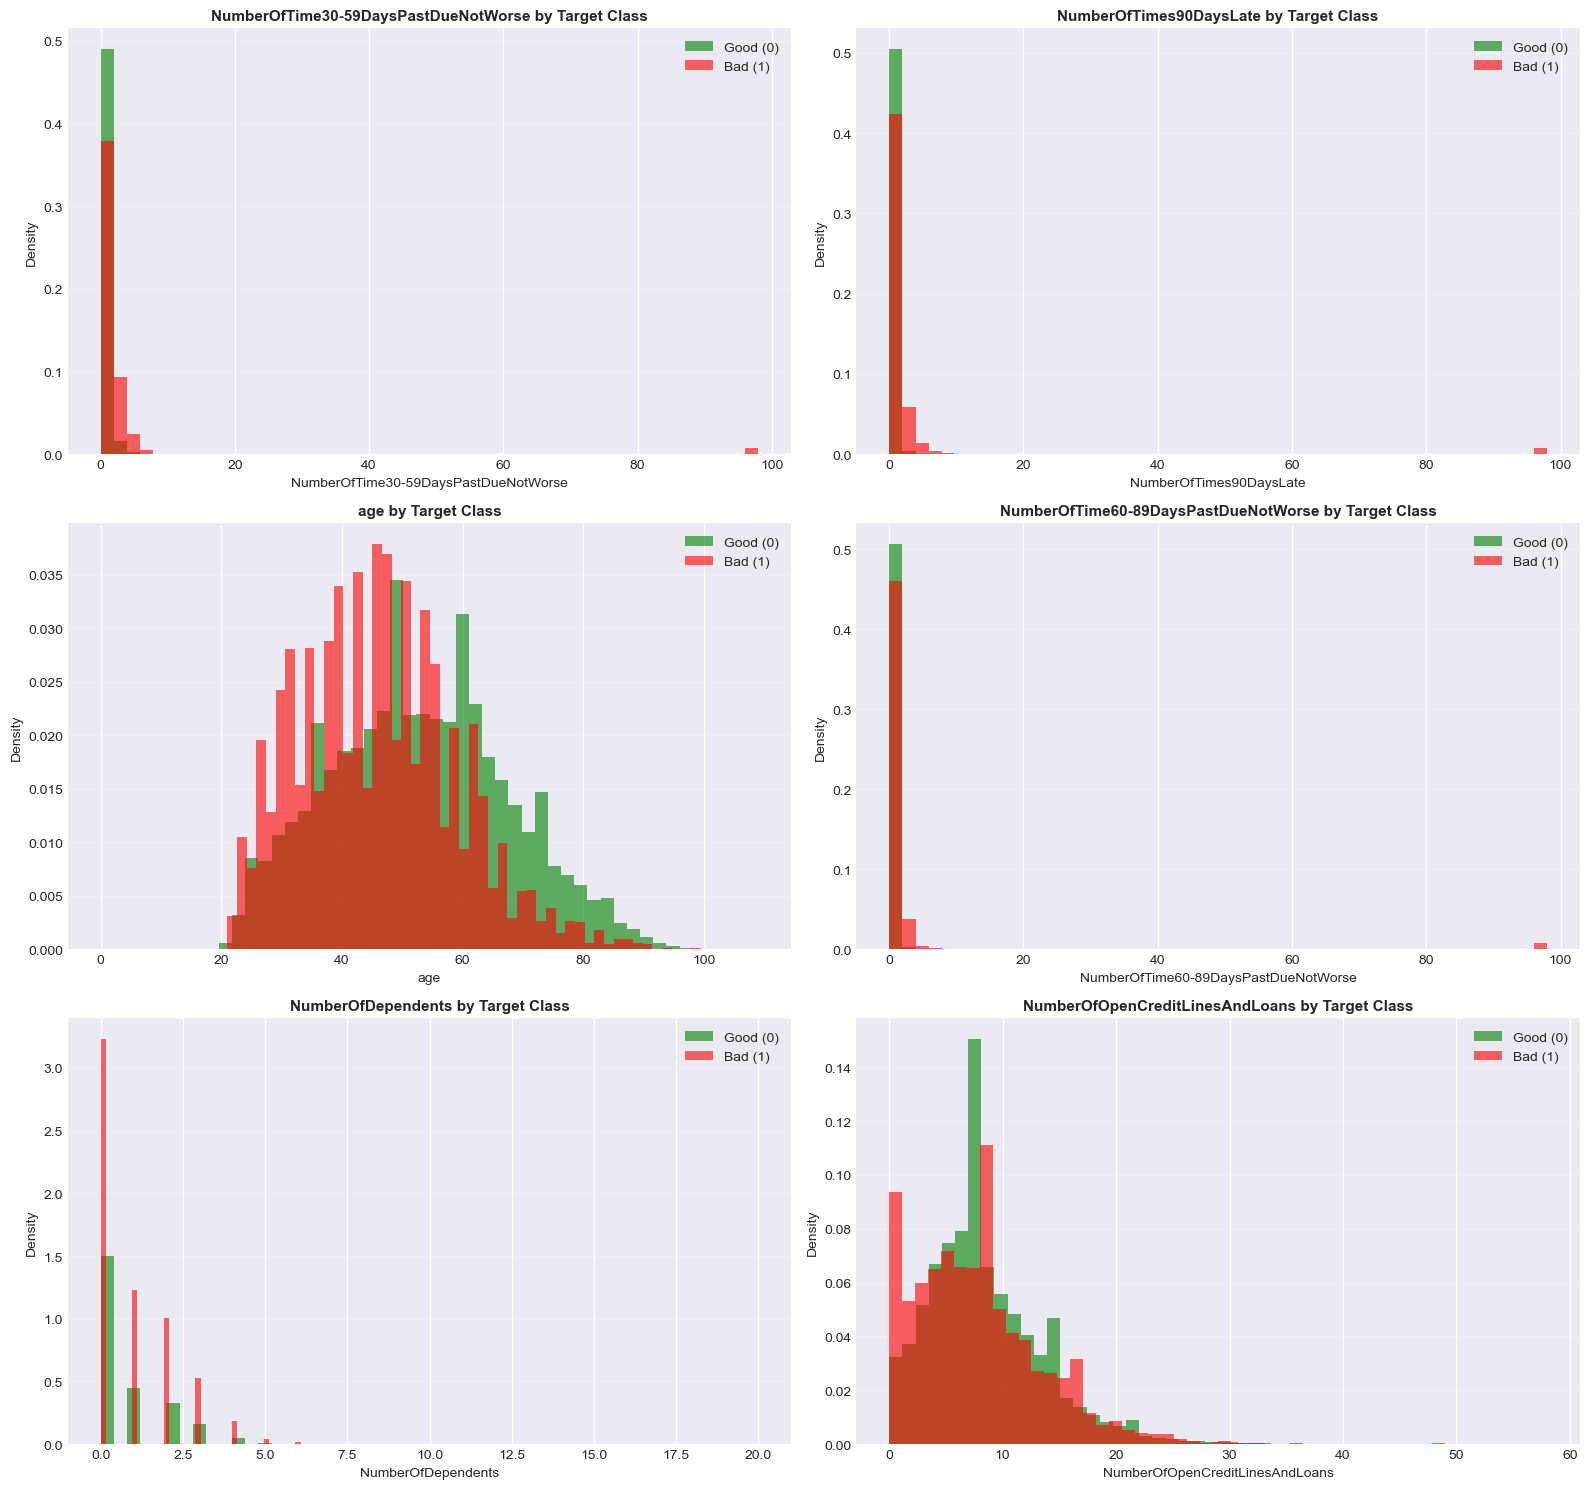

In [82]:
# Compare distributions by target class
def plot_distributions_by_target(df, features, target_col, ncols=2):
    """
    Plot feature distributions split by target class
    """
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*8, nrows*5))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    
    for idx, feature in enumerate(features):
        # Split by target
        class_0 = df[df[target_col] == 0][feature].dropna()
        class_1 = df[df[target_col] == 1][feature].dropna()
        
        # Plot overlapping histograms
        axes[idx].hist(class_0, bins=50, alpha=0.6, label='Good (0)', color='green', density=True)
        axes[idx].hist(class_1, bins=50, alpha=0.6, label='Bad (1)', color='red', density=True)
        
        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel('Density', fontsize=10)
        axes[idx].set_title(f'{feature} by Target Class', fontsize=11, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)
    
    # Hide extra subplots
    for idx in range(len(features), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + '07_distributions_by_target.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot top 6 features with highest correlation
top_features = abs(target_corr).nlargest(6).index.tolist()
plot_distributions_by_target(train_df, top_features, target_col, ncols=2)

## 9️⃣ Statistical Tests

In [83]:
# T-test for each feature between two classes
from scipy.stats import ttest_ind

print("="*80)
print("STATISTICAL SIGNIFICANCE TESTS (T-Test)")
print("="*80)
print("H0: The means of the two groups are equal")
print("H1: The means of the two groups are different")
print("Significance level: α = 0.05\n")

ttest_results = []
for feature in numerical_features:
    class_0 = train_df[train_df[target_col] == 0][feature].dropna()
    class_1 = train_df[train_df[target_col] == 1][feature].dropna()
    
    t_stat, p_value = ttest_ind(class_0, class_1)
    
    ttest_results.append({
        'Feature': feature,
        'Mean_Class_0': class_0.mean(),
        'Mean_Class_1': class_1.mean(),
        'T_Statistic': t_stat,
        'P_Value': p_value,
        'Significant': 'Yes ✓' if p_value < 0.05 else 'No ✗'
    })

ttest_df = pd.DataFrame(ttest_results).sort_values('P_Value')
display(ttest_df)

STATISTICAL SIGNIFICANCE TESTS (T-Test)
H0: The means of the two groups are equal
H1: The means of the two groups are different
Significance level: α = 0.05



,Feature,Mean_Class_0,Mean_Class_1,T_Statistic,P_Value,Significant
1,age,52.751,45.927,44.989,0.000,Yes ✓
2,NumberOfTime30-59DaysPastDueNotWorse,0.280,2.388,-49.027,0.000,Yes ✓
6,NumberOfTimes90DaysLate,0.135,2.091,-45.696,0.000,Yes ✓
8,NumberOfTime60-89DaysPastDueNotWorse,0.127,1.828,-39.814,0.000,Yes ✓
9,NumberOfDependents,0.743,0.948,-17.618,0.000,Yes ✓
5,NumberOfOpenCreditLinesAndLoans,8.494,7.882,11.496,0.000,Yes ✓
4,MonthlyIncome,6747.838,5630.826,6.849,0.000,Yes ✓
3,DebtRatio,357.151,295.121,2.944,0.003,Yes ✓
7,NumberRealEstateLoansOrLines,1.020,0.989,2.726,0.006,Yes ✓
0,RevolvingUtilizationOfUnsecuredLines,6.169,4.367,0.698,0.485,No ✗


## 🔟 Key Insights & Recommendations

In [84]:
# Summary of findings
print("="*80)
print("📊 EDA SUMMARY & KEY INSIGHTS")
print("="*80)

print("\n1️⃣ DATASET OVERVIEW")
print(f"   • Training samples: {train_df.shape[0]:,}")
print(f"   • Number of features: {len(numerical_features)}")

print("\n2️⃣ MISSING VALUES")
if len(missing_train) > 0:
    print(f"   • Features with missing values: {len(missing_train)}")
    for _, row in missing_train.iterrows():
        print(f"     - {row['Column']}: {row['Missing_Percentage']:.2f}%")
else:
    print("   • ✅ No missing values")

print("\n3️⃣ CLASS IMBALANCE")
print(f"   • Class 0 (Good): {target_counts.iloc[0]:,} ({target_pct.iloc[0]:.2f}%)")
print(f"   • Class 1 (Bad): {target_counts.iloc[1]:,} ({target_pct.iloc[1]:.2f}%)")
print(f"   • Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"   • ⚠️  Highly imbalanced dataset!")

print("\n4️⃣ OUTLIERS")
high_outliers = outlier_df[outlier_df['outliers_pct'] > 5]
if len(high_outliers) > 0:
    print(f"   • Features with >5% outliers: {len(high_outliers)}")
    for _, row in high_outliers.iterrows():
        print(f"     - {row['feature']}: {row['outliers_pct']:.2f}%")

print("\n5️⃣ TOP CORRELATED FEATURES WITH TARGET")
top_5_corr = abs(target_corr).nlargest(5)
for feature, corr in top_5_corr.items():
    print(f"   • {feature}: {target_corr[feature]:.4f}")

print("\n6️⃣ STATISTICALLY SIGNIFICANT FEATURES")
sig_features = ttest_df[ttest_df['Significant'] == 'Yes ✓']
print(f"   • {len(sig_features)}/{len(numerical_features)} features are statistically significant (p < 0.05)")

print("\n" + "="*80)
print("💡 RECOMMENDATIONS FOR NEXT STEPS")
print("="*80)

print("\n1. DATA PREPROCESSING:")
if len(missing_train) > 0:
    print("   ✓ Handle missing values (imputation)")
print("   ✓ Handle outliers (capping or removal)")
print("   ✓ Feature scaling (StandardScaler)")

print("\n2. IMBALANCED DATA:")
print("   ✓ Use class_weight='balanced' in models")
print("   ✓ Stratified train-test split")

print("\n3. FEATURE ENGINEERING:")
print("   ✓ Create new features from existing ones")
print("   ✓ Interaction features")
print("   ✓ Feature selection based on correlation/importance")

print("\n4. MODELING:")
print("   ✓ Start with Logistic Regression (baseline)")
print("   ✓ Try tree-based models (Random Forest, XGBoost, LightGBM)")
print("   ✓ Focus on ROC-AUC and Recall metrics")

print("\n" + "="*80)

📊 EDA SUMMARY & KEY INSIGHTS

1️⃣ DATASET OVERVIEW
   • Training samples: 150,000
   • Number of features: 10

2️⃣ MISSING VALUES
   • Features with missing values: 2
     - MonthlyIncome: 19.82%
     - NumberOfDependents: 2.62%

3️⃣ CLASS IMBALANCE
   • Class 0 (Good): 139,974 (93.32%)
   • Class 1 (Bad): 10,026 (6.68%)
   • Imbalance ratio: 13.96:1
   • ⚠️  Highly imbalanced dataset!

4️⃣ OUTLIERS
   • Features with >5% outliers: 5
     - DebtRatio: 20.87%
     - NumberOfTime30-59DaysPastDueNotWorse: 15.99%
     - NumberOfDependents: 9.13%
     - NumberOfTimes90DaysLate: 5.56%
     - NumberOfTime60-89DaysPastDueNotWorse: 5.07%

5️⃣ TOP CORRELATED FEATURES WITH TARGET
   • NumberOfTime30-59DaysPastDueNotWorse: 0.1256
   • NumberOfTimes90DaysLate: 0.1172
   • age: -0.1154
   • NumberOfTime60-89DaysPastDueNotWorse: 0.1023
   • NumberOfDependents: 0.0460

6️⃣ STATISTICALLY SIGNIFICANT FEATURES
   • 9/10 features are statistically significant (p < 0.05)

💡 RECOMMENDATIONS FOR NEXT STEPS



## 📝 Save EDA Results

In [85]:
# Save summary statistics
report_dir = '../reports/[1] Ket qua EDA/'

summary_stats.to_csv(report_dir + 'summary_statistics.csv')
print("✅ Saved: summary_statistics.csv")

# Save correlation matrix
correlation_matrix.to_csv(report_dir + 'correlation_matrix.csv')
print("✅ Saved: correlation_matrix.csv")

# Save outlier analysis
outlier_df.to_csv(report_dir + 'outlier_analysis.csv', index=False)
print("✅ Saved: outlier_analysis.csv")

# Save t-test results
ttest_df.to_csv(report_dir + 'ttest_results.csv', index=False)
print("✅ Saved: ttest_results.csv")

print(f"\n✅ EDA completed successfully!")
print(f"📊 All visualizations saved in: {FIGURES_DIR}")
print(f"📄 All analysis results saved in: {report_dir}")

✅ Saved: summary_statistics.csv
✅ Saved: correlation_matrix.csv
✅ Saved: outlier_analysis.csv
✅ Saved: ttest_results.csv

✅ EDA completed successfully!
📊 All visualizations saved in: ../reports/[1] Ket qua EDA/figures/
📄 All analysis results saved in: ../reports/[1] Ket qua EDA/


---
## Next Steps

After completing EDA, proceed to:
1. **02_Preprocessing.ipynb** - Data cleaning, preprocessing & feature engineering
2. **03_Model_Building.ipynb** - Train 5 ML models
3. **04_Model_Evaluation.ipynb** - Compare and evaluate models
4. **05_Final_Report.ipynb** - Final report & submission

---
**Author**: QuangMinh | **Course**: MLE501 | **Date**: 2026-03-09